# EDA — Distribusi Transaksi Harian & Mingguan per Kategori per User

Analisis distribusi:
1. **Nominal transaksi harian** per kategori (aggregat seluruh user)
2. **Jumlah transaksi per minggu** per kategori per user

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 10

DATA_DIR = '../../../data/new'

df_trx = pd.read_csv(f'{DATA_DIR}/df_transaksi.csv', parse_dates=['timestamp'])
df_nas = pd.read_csv(f'{DATA_DIR}/df_nasabah.csv')

print(f'Transaksi : {df_trx.shape}')
print(f'Nasabah   : {df_nas.shape}')
df_trx.head(3)

Transaksi : (141454, 14)
Nasabah   : (500, 11)


,id_transaksi,id_user,timestamp,tipe_mutasi,deskripsi_mutasi,catatan_mutasi,mcc,nominal,sisa_saldo,kategori_besar,kategori_detail,label_anomali,gt_kategori_besar,gt_kategori_detail
0,TRX-12347,USR-321,2026-01-01 00:00:00,Debit,SOLARIA,-,5812,59815.47,8035389.53,Wants,F&B dan Nongkrong,0,Needs,F&B dan Nongkrong
1,TRX-13487,USR-482,2026-01-01 00:18:00,Debit,INDOMIE REBUS WARUNG,-,5814,11080.27,14216825.25,Wants,F&B dan Nongkrong,0,Needs,F&B dan Nongkrong
2,TRX-14356,USR-367,2026-01-01 00:42:00,Debit,BAKSO LAPANGAN TEMBAK,-,5812,34532.51,6522926.39,Wants,F&B dan Nongkrong,0,Needs,F&B dan Nongkrong


In [2]:

df = df_trx.copy()

df['tanggal']    = df['timestamp'].dt.date
df['minggu_num'] = df['timestamp'].dt.isocalendar().week.astype(int)
df['hari_nama']  = df['timestamp'].dt.day_name()


df = df.dropna(subset=['kategori_detail', 'kategori_besar'])
df_debit = df[df['tipe_mutasi'] == 'Debit'].copy()

KATEGORI_ORDER = sorted(df['kategori_detail'].unique())
print('Kategori Detail:', KATEGORI_ORDER)
print('Rentang tanggal:', df['tanggal'].min(), '-', df['tanggal'].max())

Kategori Detail: ['Belanja Online & Fashion', 'F&B dan Nongkrong', 'Groceries & Kebutuhan Pokok', 'Hiburan & Langganan', 'Investasi & Finansial', 'Kesehatan & Perawatan Diri', 'Pemasukan Tambahan', 'Pendapatan Bulanan', 'Produktivitas & Digital', 'Tagihan & Utilitas', 'Transfer P2P', 'Transportasi']
Rentang tanggal: 2026-01-01 - 2026-03-31


---
## 1. Distribusi Nominal Harian per Kategori (seluruh user)

Setiap titik = total nominal transaksi satu user dalam satu hari untuk satu kategori (Debit).

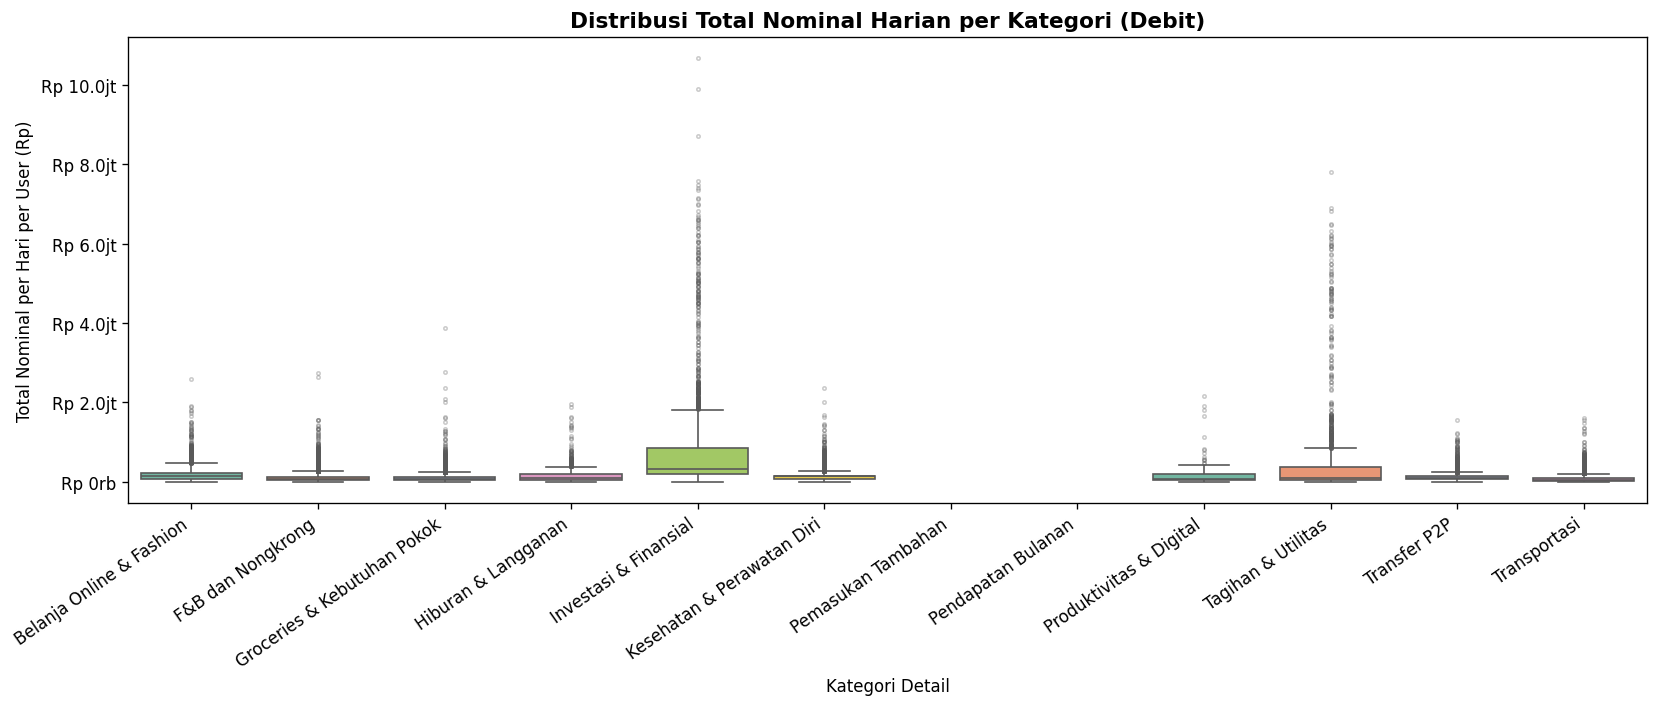


Statistik Nominal Harian per Kategori (Debit):


,count,mean,std,min,25%,50%,75%,95%,max
kategori_detail,,,,,,,,,
Belanja Online & Fashion,4384.0,183794.0,186873.0,2000.0,68931.0,138277.0,231546.0,520177.0,2596726.0
F&B dan Nongkrong,25186.0,97858.0,107921.0,2000.0,32195.0,67051.0,123391.0,301268.0,2735532.0
Groceries & Kebutuhan Pokok,10608.0,97599.0,124419.0,2000.0,34874.0,58646.0,116541.0,308940.0,3877165.0
Hiburan & Langganan,5219.0,134812.0,120674.0,2000.0,54900.0,102038.0,186000.0,302188.0,1967255.0
Investasi & Finansial,2481.0,797473.0,1206120.0,1149.0,194118.0,324000.0,846843.0,3196071.0,10679201.0
Kesehatan & Perawatan Diri,4019.0,157023.0,148188.0,2000.0,76124.0,150000.0,150000.0,416766.0,2371642.0
Produktivitas & Digital,1608.0,118782.0,141806.0,3906.0,35727.0,70000.0,201042.0,350000.0,2160906.0
Tagihan & Utilitas,1351.0,534687.0,1155238.0,4407.0,40670.0,92513.0,363017.0,3289003.0,7804613.0
Transfer P2P,7067.0,108213.0,95095.0,2000.0,55608.0,84837.0,131071.0,250701.0,1559165.0


In [3]:
daily_user_kat = (
    df_debit
    .groupby(['id_user', 'tanggal', 'kategori_detail'])['nominal']
    .sum()
    .reset_index(name='total_nominal')
)

fig, ax = plt.subplots(figsize=(14, 6))

sns.boxplot(
    data=daily_user_kat,
    x='kategori_detail',
    y='total_nominal',
    order=KATEGORI_ORDER,
    palette='Set2',
    flierprops=dict(marker='o', markersize=2, alpha=0.3),
    ax=ax
)

ax.set_title('Distribusi Total Nominal Harian per Kategori (Debit)', fontsize=13, fontweight='bold')
ax.set_xlabel('Kategori Detail')
ax.set_ylabel('Total Nominal per Hari per User (Rp)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'Rp {x/1e6:.1f}jt' if x >= 1e6 else f'Rp {x/1e3:.0f}rb'
))
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
plt.tight_layout()
plt.show()

print('\nStatistik Nominal Harian per Kategori (Debit):')
daily_user_kat.groupby('kategori_detail')['total_nominal'].describe(
    percentiles=[.25, .5, .75, .95]
).round(0)

---
## 2. Rata-rata Nominal Harian per Kategori — per Hari dalam Seminggu

Heatmap pola pengeluaran berdasarkan hari (Senin–Minggu).

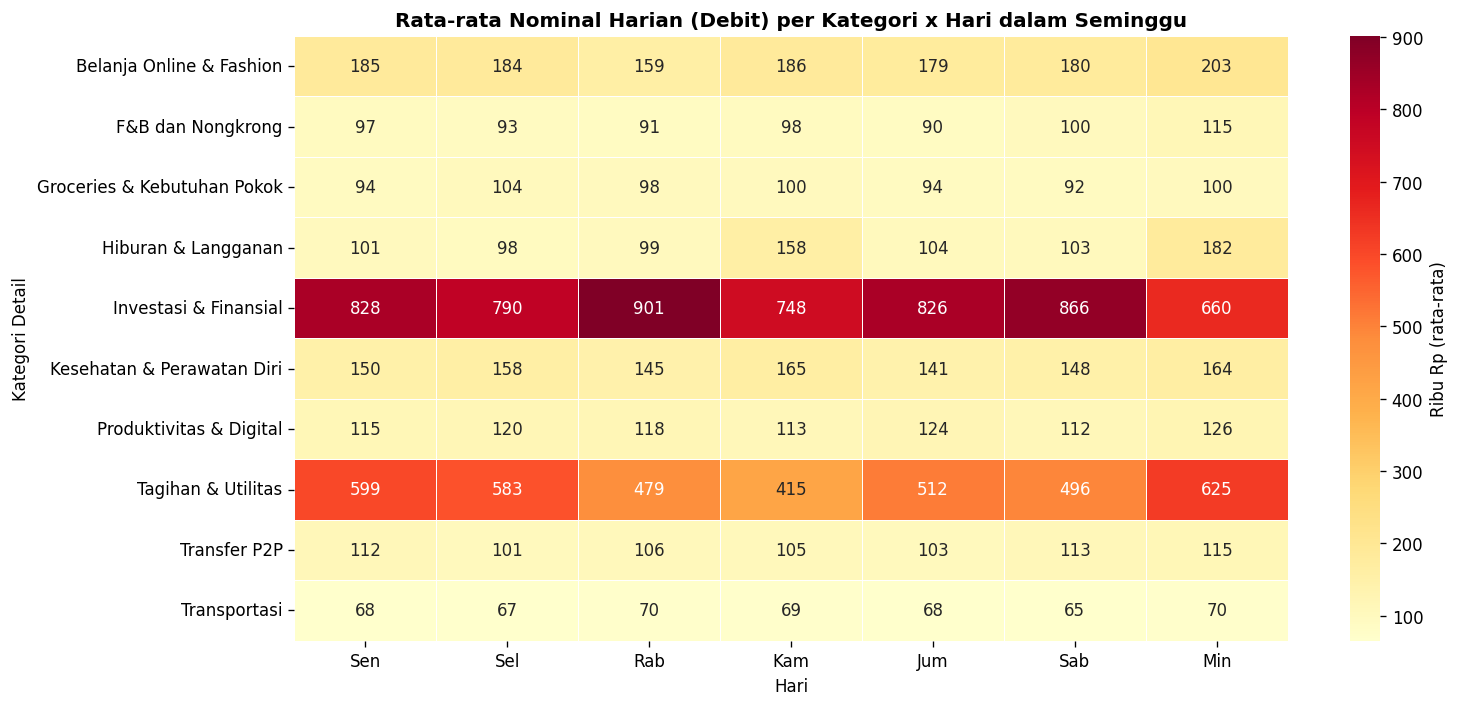

In [4]:
daily_user_kat['hari_nama'] = pd.to_datetime(daily_user_kat['tanggal']).dt.day_name()

DAY_ORDER = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
DAY_LABEL = ['Sen', 'Sel', 'Rab', 'Kam', 'Jum', 'Sab', 'Min']

pivot_harian = (
    daily_user_kat
    .groupby(['kategori_detail', 'hari_nama'])['total_nominal']
    .mean()
    .unstack('hari_nama')
    .reindex(columns=DAY_ORDER)
)
pivot_harian.columns = DAY_LABEL

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(
    pivot_harian / 1e3,
    annot=True, fmt='.0f', cmap='YlOrRd',
    linewidths=0.4, linecolor='white',
    cbar_kws={'label': 'Ribu Rp (rata-rata)'},
    ax=ax
)
ax.set_title('Rata-rata Nominal Harian (Debit) per Kategori x Hari dalam Seminggu', fontsize=12, fontweight='bold')
ax.set_xlabel('Hari')
ax.set_ylabel('Kategori Detail')
plt.tight_layout()
plt.show()

---
## 3. Distribusi Jumlah Transaksi per Minggu per Kategori per User

Setiap titik = jumlah transaksi satu user dalam satu minggu untuk satu kategori.

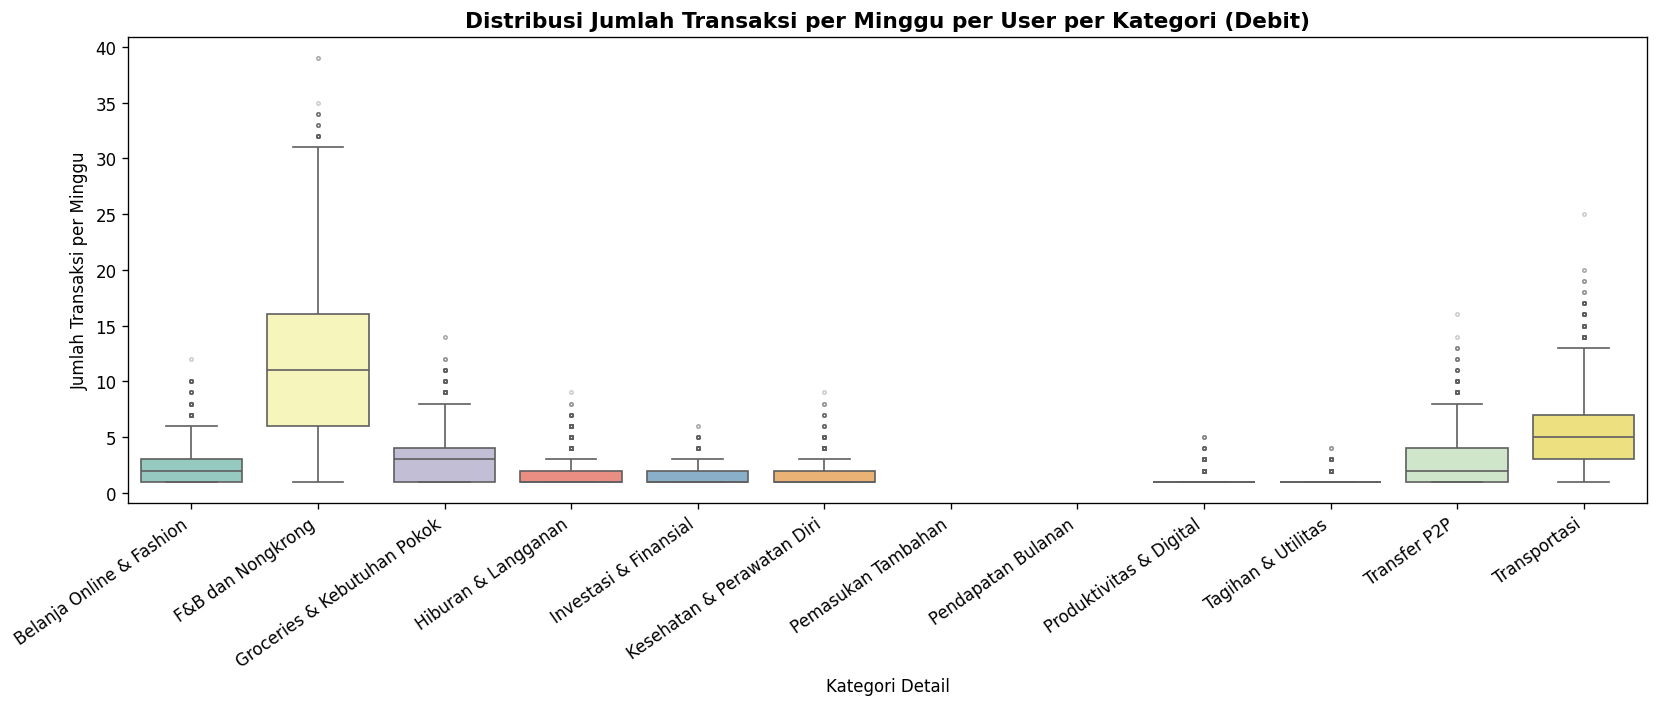


Statistik Jumlah Transaksi per Minggu per Kategori:


,count,mean,std,min,25%,50%,75%,95%,max
kategori_detail,,,,,,,,,
Belanja Online & Fashion,2368.0,2.34,1.80,1.0,1.0,2.0,3.0,6.0,12.0
F&B dan Nongkrong,5574.0,11.74,6.97,1.0,6.0,11.0,16.0,24.0,39.0
Groceries & Kebutuhan Pokok,4473.0,3.09,1.98,1.0,1.0,3.0,4.0,7.0,14.0
Hiburan & Langganan,3344.0,1.89,1.26,1.0,1.0,1.0,2.0,5.0,9.0
Investasi & Finansial,1859.0,1.42,0.76,1.0,1.0,1.0,2.0,3.0,6.0
Kesehatan & Perawatan Diri,2928.0,1.54,0.93,1.0,1.0,1.0,2.0,3.0,9.0
Produktivitas & Digital,1321.0,1.28,0.59,1.0,1.0,1.0,1.0,2.0,5.0
Tagihan & Utilitas,1174.0,1.19,0.47,1.0,1.0,1.0,1.0,2.0,4.0
Transfer P2P,3205.0,2.99,2.25,1.0,1.0,2.0,4.0,8.0,16.0


In [5]:
# Aggregasi: hitung transaksi per user per minggu per kategori
weekly_user_kat = (
    df_debit
    .groupby(['id_user', 'minggu_num', 'kategori_detail'])['id_transaksi']
    .count()
    .reset_index(name='jumlah_trx')
)

fig, ax = plt.subplots(figsize=(14, 6))

sns.boxplot(
    data=weekly_user_kat,
    x='kategori_detail',
    y='jumlah_trx',
    order=KATEGORI_ORDER,
    palette='Set3',
    flierprops=dict(marker='o', markersize=2, alpha=0.3),
    ax=ax
)

ax.set_title('Distribusi Jumlah Transaksi per Minggu per User per Kategori (Debit)', fontsize=13, fontweight='bold')
ax.set_xlabel('Kategori Detail')
ax.set_ylabel('Jumlah Transaksi per Minggu')
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
plt.tight_layout()
plt.show()

print('\nStatistik Jumlah Transaksi per Minggu per Kategori:')
weekly_user_kat.groupby('kategori_detail')['jumlah_trx'].describe(
    percentiles=[.25, .5, .75, .95]
).round(2)

---
## 4. Heatmap — Rata-rata Jumlah Transaksi per Minggu (Kategori x Minggu ke-N)

Tren mingguan masing-masing kategori sepanjang 3 bulan data.

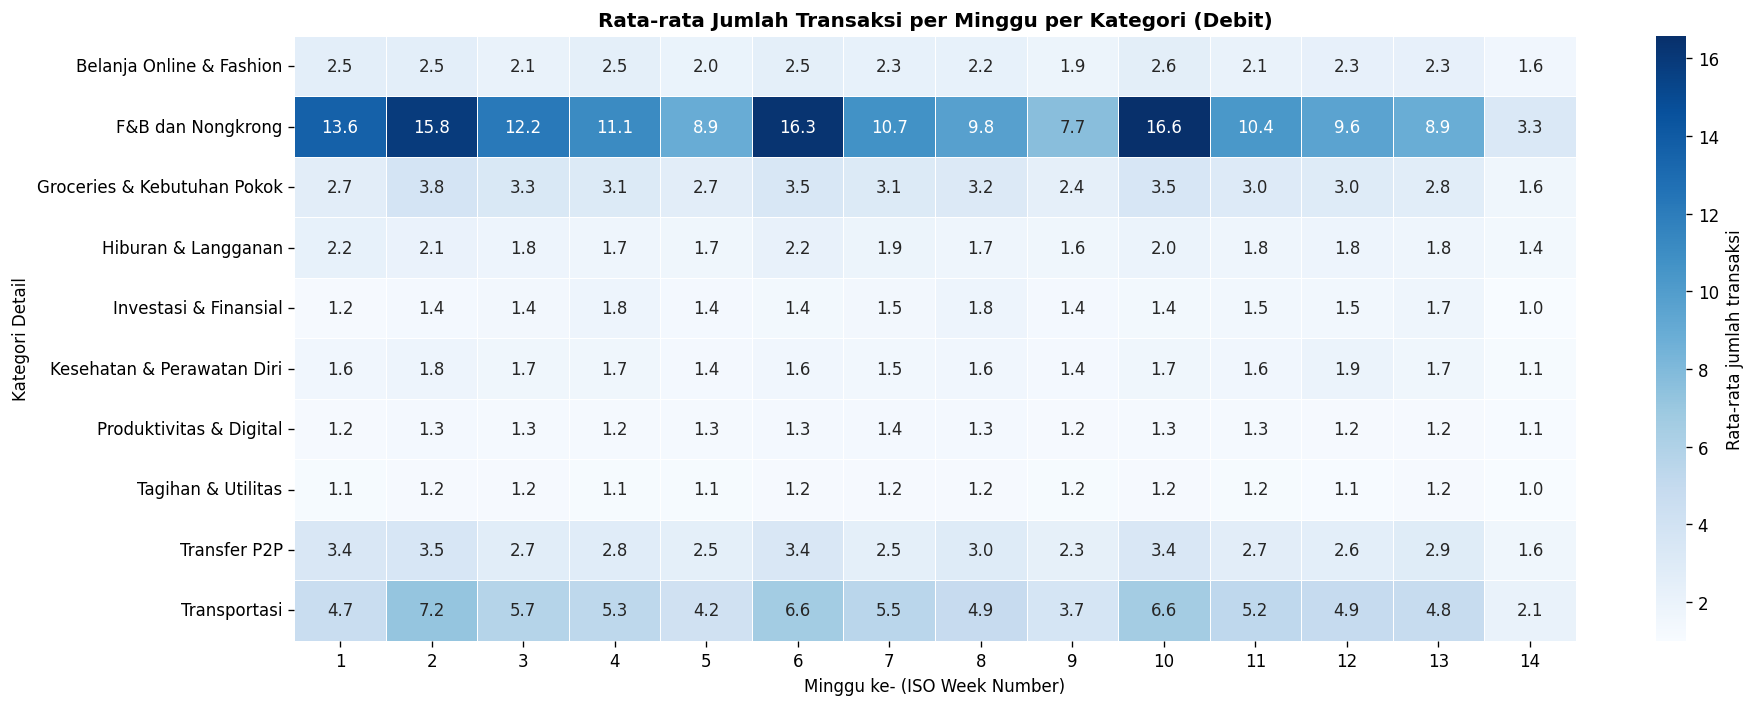

In [6]:
pivot_weekly = (
    weekly_user_kat
    .groupby(['kategori_detail', 'minggu_num'])['jumlah_trx']
    .mean()
    .unstack('minggu_num')
)

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(
    pivot_weekly,
    annot=True, fmt='.1f', cmap='Blues',
    linewidths=0.3, linecolor='white',
    cbar_kws={'label': 'Rata-rata jumlah transaksi'},
    ax=ax
)
ax.set_title('Rata-rata Jumlah Transaksi per Minggu per Kategori (Debit)', fontsize=12, fontweight='bold')
ax.set_xlabel('Minggu ke- (ISO Week Number)')
ax.set_ylabel('Kategori Detail')
plt.tight_layout()
plt.show()

---
## 5. Nominal Mingguan per Kategori — Tren & Distribusi Antar-User

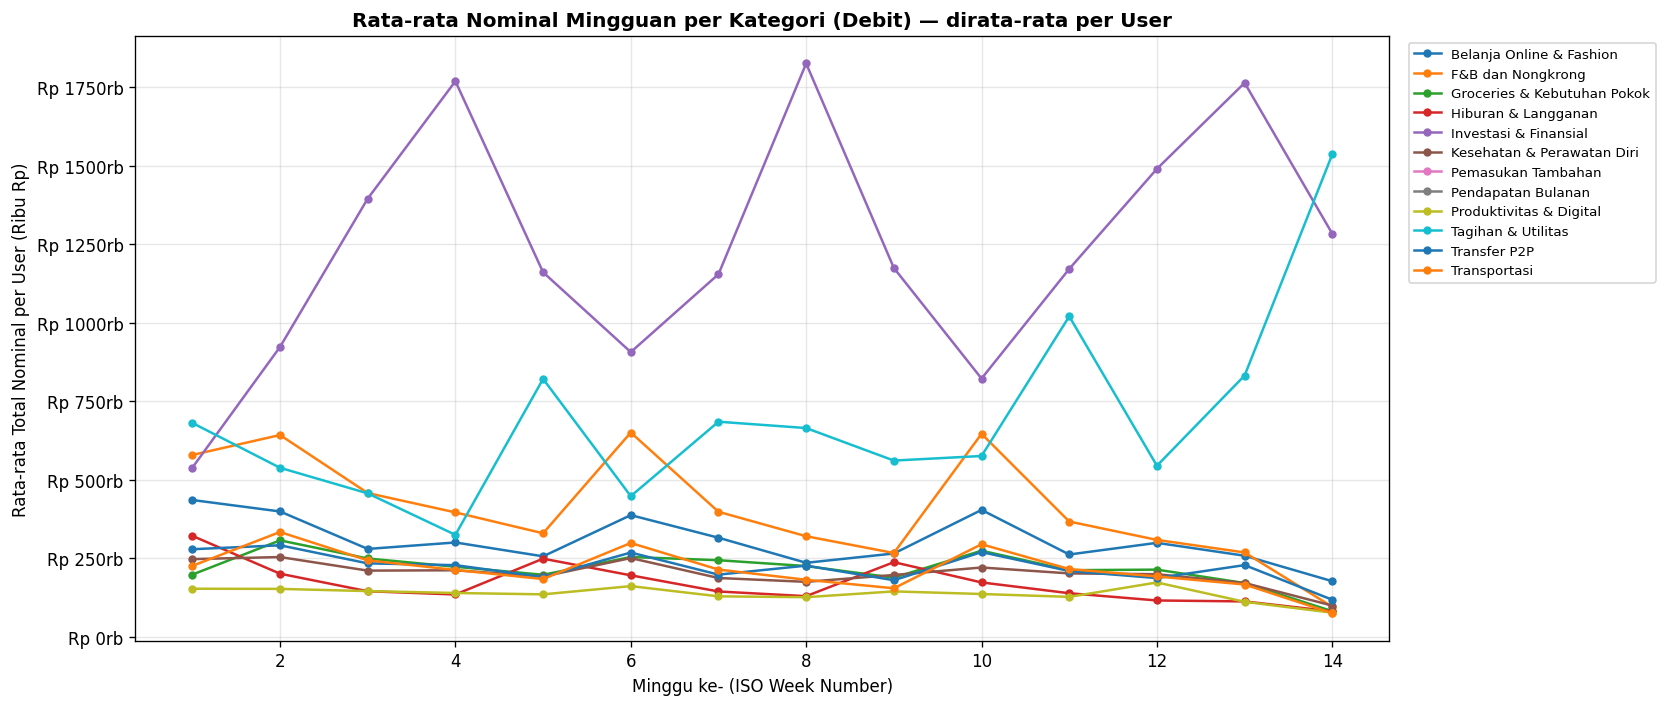

In [7]:
weekly_nominal = (
    df_debit
    .groupby(['id_user', 'minggu_num', 'kategori_detail'])['nominal']
    .sum()
    .reset_index(name='total_nominal')
)

agg_weekly = (
    weekly_nominal
    .groupby(['minggu_num', 'kategori_detail'])['total_nominal']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 6))

palette = sns.color_palette('tab10', n_colors=len(KATEGORI_ORDER))
for i, kat in enumerate(KATEGORI_ORDER):
    subset = agg_weekly[agg_weekly['kategori_detail'] == kat]
    ax.plot(subset['minggu_num'], subset['total_nominal'] / 1e3,
            marker='o', markersize=4, label=kat, color=palette[i])

ax.set_title('Rata-rata Nominal Mingguan per Kategori (Debit) — dirata-rata per User', fontsize=12, fontweight='bold')
ax.set_xlabel('Minggu ke- (ISO Week Number)')
ax.set_ylabel('Rata-rata Total Nominal per User (Ribu Rp)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'Rp {x:.0f}rb'))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

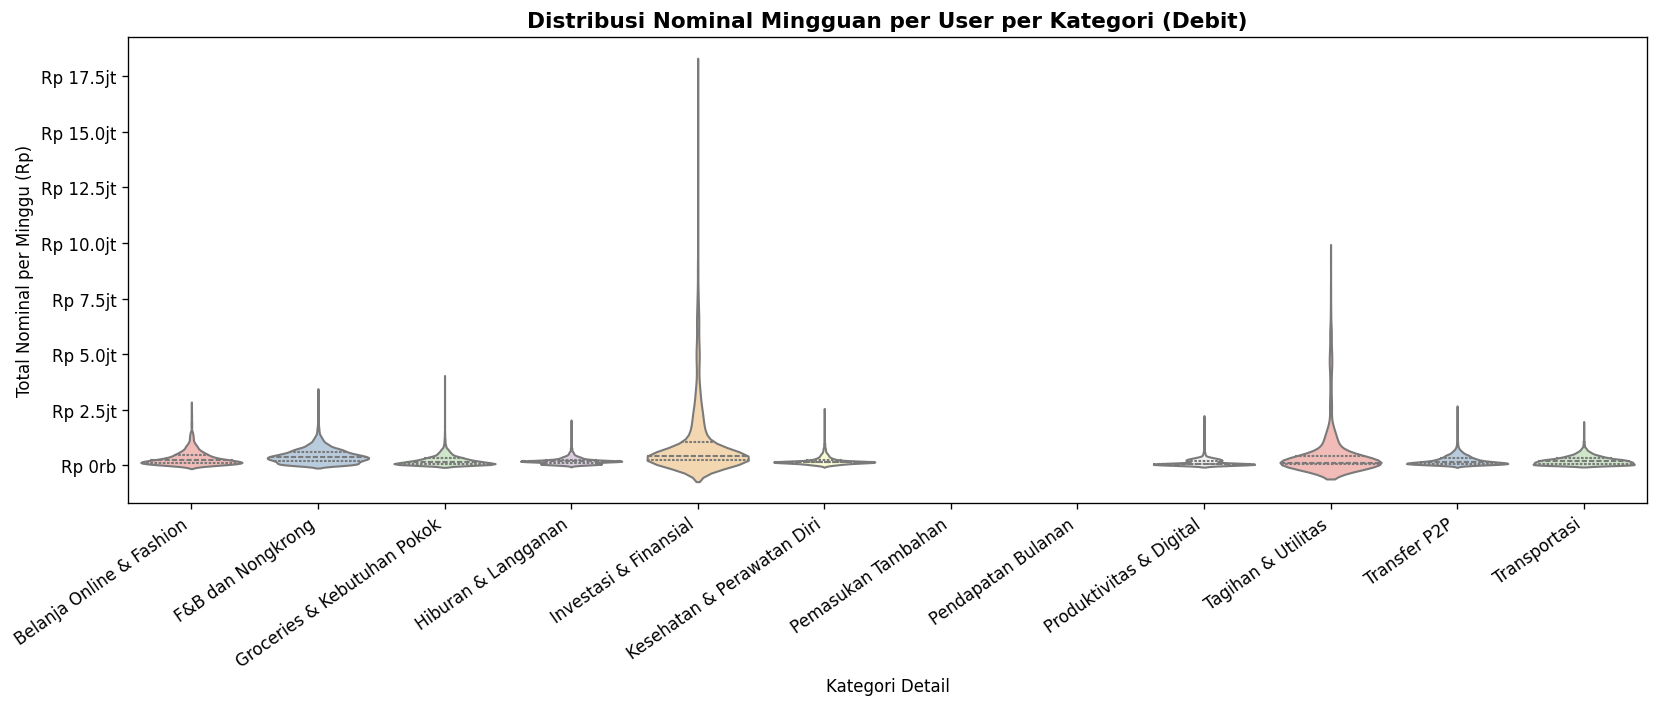

In [8]:
fig, ax = plt.subplots(figsize=(14, 6))

sns.violinplot(
    data=weekly_nominal,
    x='kategori_detail',
    y='total_nominal',
    order=KATEGORI_ORDER,
    palette='Pastel1',
    inner='quartile',
    ax=ax
)

ax.set_title('Distribusi Nominal Mingguan per User per Kategori (Debit)', fontsize=13, fontweight='bold')
ax.set_xlabel('Kategori Detail')
ax.set_ylabel('Total Nominal per Minggu (Rp)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'Rp {x/1e6:.1f}jt' if x >= 1e6 else f'Rp {x/1e3:.0f}rb'
))
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
plt.tight_layout()
plt.show()

---
## 6. Rangkuman — Tabel Statistik Mingguan per Kategori

In [9]:
summary_nominal = weekly_nominal.groupby('kategori_detail')['total_nominal'].agg(
    median_nominal = 'median',
    mean_nominal   = 'mean',
    p75_nominal    = lambda x: x.quantile(0.75),
    p95_nominal    = lambda x: x.quantile(0.95),
)

summary_trx = weekly_user_kat.groupby('kategori_detail')['jumlah_trx'].agg(
    median_trx = 'median',
    mean_trx   = 'mean',
    p75_trx    = lambda x: x.quantile(0.75),
    p95_trx    = lambda x: x.quantile(0.95),
)

summary = summary_nominal.join(summary_trx).round(1)
summary.columns = [
    'Median Nominal/Minggu', 'Mean Nominal/Minggu', 'P75 Nominal', 'P95 Nominal',
    'Median Trx/Minggu', 'Mean Trx/Minggu', 'P75 Trx', 'P95 Trx'
]

pd.set_option('display.float_format', '{:,.1f}'.format)
summary

,Median Nominal/Minggu,Mean Nominal/Minggu,P75 Nominal,P95 Nominal,Median Trx/Minggu,Mean Trx/Minggu,P75 Trx,P95 Trx
kategori_detail,,,,,,,,
Belanja Online & Fashion,"228,215.5","340,266.7","462,838.2","1,009,384.8",2.0,2.3,3.0,6.0
F&B dan Nongkrong,"381,564.1","442,169.7","617,027.0","1,071,602.4",11.0,11.7,16.0,24.0
Groceries & Kebutuhan Pokok,"166,476.3","231,461.7","316,553.4","662,236.9",3.0,3.1,4.0,7.0
Hiburan & Langganan,"186,000.0","210,401.1","250,386.9","483,915.2",1.0,1.9,2.0,5.0
Investasi & Finansial,"403,259.9","1,064,298.3","1,071,785.1","4,952,792.7",1.0,1.4,2.0,3.0
Kesehatan & Perawatan Diri,"150,000.0","215,531.2","235,016.5","584,881.6",1.0,1.5,2.0,3.0
Produktivitas & Digital,"79,000.0","144,588.7","215,000.0","359,000.0",1.0,1.3,1.0,2.0
Tagihan & Utilitas,"126,438.5","615,299.7","422,515.6","3,858,884.5",1.0,1.2,1.0,2.0
Transfer P2P,"163,958.4","238,609.4","330,389.6","645,512.1",2.0,3.0,4.0,8.0


---
## 7. Rincian per User — Nominal & Jumlah Transaksi per Kategori per Minggu

Tabel pivot per user: baris = kategori, kolom = minggu (sub-kolom: **Nominal** dan **Trx**).

In [10]:
def fmt_nominal(x):
    if pd.isna(x) or x == 0:
        return '-'
    elif x >= 1_000_000:
        return f'Rp {x/1_000_000:.2f}jt'
    return f'Rp {x/1_000:.0f}rb'


def fmt_trx(x):
    if pd.isna(x) or x == 0:
        return '-'
    return str(int(x))


def user_weekly_table(user_id, df_debit):
    df_u = df_debit[df_debit['id_user'] == user_id].copy()

    grp = df_u.groupby(['kategori_detail', 'minggu_num']).agg(
        nominal=('nominal', 'sum'),
        trx=('id_transaksi', 'count')
    ).reset_index()

    weeks = sorted(grp['minggu_num'].unique())

    piv_nominal = grp.pivot(index='kategori_detail', columns='minggu_num', values='nominal').fillna(0)
    piv_trx     = grp.pivot(index='kategori_detail', columns='minggu_num', values='trx').fillna(0)

    frames = []
    for w in weeks:
        col_label = f'Minggu {w}'
        frames.append(piv_nominal[w].rename((col_label, 'Nominal')))
        frames.append(piv_trx[w].rename((col_label, 'Trx')))

    result = pd.concat(frames, axis=1)
    result.columns = pd.MultiIndex.from_tuples(result.columns)
    result.index.name = 'Kategori'

    display_df = result.copy().astype(object)
    for w in weeks:
        col_label = f'Minggu {w}'
        display_df[(col_label, 'Nominal')] = result[(col_label, 'Nominal')].map(fmt_nominal)
        display_df[(col_label, 'Trx')]     = result[(col_label, 'Trx')].map(fmt_trx)

    return display_df


# Pilih 2 user sebagai contoh
SAMPLE_USERS = ['USR-001', 'USR-002']

for uid in SAMPLE_USERS:
    sep = '=' * 80
    print(f'\n{sep}')
    print(f'  USER: {uid}')
    print(sep)
    tbl = user_weekly_table(uid, df_debit)
    display(tbl)


  USER: USR-001


Minggu 1       Minggu 2     Minggu 3      \
                              Nominal Trx    Nominal Trx  Nominal Trx   
Kategori                                                                
Belanja Online & Fashion     Rp 473rb   6  Rp 1.04jt   5        -   -   
F&B dan Nongkrong            Rp 814rb  19   Rp 966rb  27  Rp 63rb   3   
Groceries & Kebutuhan Pokok  Rp 434rb   5   Rp 261rb   7        -   -   
Hiburan & Langganan          Rp 186rb   1    Rp 87rb   1        -   -   
Investasi & Finansial        Rp 313rb   1          -   -        -   -   
Kesehatan & Perawatan Diri   Rp 150rb   1   Rp 127rb   3        -   -   
Produktivitas & Digital       Rp 70rb   1   Rp 215rb   4        -   -   
Tagihan & Utilitas            Rp 85rb   2          -   -        -   -   
Transfer P2P                 Rp 500rb   4   Rp 238rb   4        -   -   
Transportasi                 Rp 102rb   3   Rp 500rb  14   Rp 4rb   1   

                             Minggu 5      Minggu 6      Minggu 7      \
                              Nominal Trx   Nominal Trx   Nominal Trx   
Kategori                                                                
Belanja Online & Fashion            -   -         -   -         -   -   
F&B dan Nongkrong              Rp 8rb   1  Rp 709rb  20  Rp 304rb   9   
Groceries & Kebutuhan Pokok         -   -   Rp 45rb   2   Rp 53rb   1   
Hiburan & Langganan          Rp 186rb   1   Rp 69rb   1         -   -   
Investasi & Finansial               -   -  Rp 313rb   1         -   -   
Kesehatan & Perawatan Diri   Rp 150rb   1  Rp 112rb   1   Rp 62rb   1   
Produktivitas & Digital             -   -         -   -         -   -   
Tagihan & Utilitas                  -   -  Rp 126rb   1         -   -   
Transfer P2P                 Rp 132rb   1  Rp 408rb   5         -   -   
Transportasi                        -   -  Rp 447rb   7    Rp 4rb   1   

                             Minggu 9      Minggu 10     Minggu 11      
                              Nominal Trx    Nominal Trx   Nominal Trx  
Kategori                                                                
Belanja Online & Fashion            -   -          -   -         -   -  
F&B dan Nongkrong             Rp 20rb   1  Rp 1.02jt  13   Rp 31rb   3  
Groceries & Kebutuhan Pokok         -   -   Rp 192rb   2         -   -  
Hiburan & Langganan          Rp 186rb   1   Rp 115rb   1         -   -  
Investasi & Finansial        Rp 313rb   1          -   -         -   -  
Kesehatan & Perawatan Diri   Rp 150rb   1   Rp 296rb   1         -   -  
Produktivitas & Digital      Rp 351rb   1          -   -         -   -  
Tagihan & Utilitas                  -   -          -   -         -   -  
Transfer P2P                        -   -   Rp 147rb   2         -   -  
Transportasi                  Rp 21rb   1   Rp 276rb   6   Rp 11rb   1


  USER: USR-002


Minggu 1     Minggu 2     Minggu 4      \
                               Nominal Trx  Nominal Trx  Nominal Trx   
Kategori                                                               
Belanja Online & Fashion      Rp 427rb   3   Rp 3rb   1        -   -   
F&B dan Nongkrong            Rp 1.49jt  27  Rp 17rb   1   Rp 2rb   1   
Groceries & Kebutuhan Pokok   Rp 333rb   5        -   -        -   -   
Hiburan & Langganan           Rp 186rb   1        -   -        -   -   
Investasi & Finansial                -   -        -   -        -   -   
Kesehatan & Perawatan Diri    Rp 150rb   1        -   -        -   -   
Produktivitas & Digital        Rp 52rb   1        -   -        -   -   
Tagihan & Utilitas                   -   -        -   -        -   -   
Transfer P2P                  Rp 157rb   2        -   -        -   -   
Transportasi                  Rp 317rb   7        -   -        -   -   

                             Minggu 5      Minggu 6      Minggu 8      \
                              Nominal Trx   Nominal Trx   Nominal Trx   
Kategori                                                                
Belanja Online & Fashion            -   -    Rp 2rb   1         -   -   
F&B dan Nongkrong            Rp 303rb   6  Rp 225rb  11   Rp 32rb   3   
Groceries & Kebutuhan Pokok         -   -  Rp 271rb   2  Rp 133rb   2   
Hiburan & Langganan          Rp 372rb   2   Rp 96rb   2         -   -   
Investasi & Finansial               -   -         -   -         -   -   
Kesehatan & Perawatan Diri   Rp 150rb   1  Rp 150rb   1         -   -   
Produktivitas & Digital             -   -   Rp 33rb   1  Rp 252rb   2   
Tagihan & Utilitas            Rp 49rb   1   Rp 20rb   1         -   -   
Transfer P2P                        -   -  Rp 217rb   2         -   -   
Transportasi                  Rp 34rb   2  Rp 278rb   6         -   -   

                             Minggu 9     Minggu 10     Minggu 11      \
                              Nominal Trx   Nominal Trx   Nominal Trx   
Kategori                                                                
Belanja Online & Fashion     Rp 345rb   2  Rp 184rb   1         -   -   
F&B dan Nongkrong            Rp 244rb   4  Rp 444rb  10         -   -   
Groceries & Kebutuhan Pokok    Rp 4rb   1  Rp 184rb   4         -   -   
Hiburan & Langganan          Rp 186rb   1         -   -         -   -   
Investasi & Finansial        Rp 220rb   1         -   -         -   -   
Kesehatan & Perawatan Diri   Rp 150rb   1   Rp 41rb   1         -   -   
Produktivitas & Digital             -   -         -   -         -   -   
Tagihan & Utilitas                  -   -         -   -         -   -   
Transfer P2P                 Rp 155rb   1  Rp 336rb   4         -   -   
Transportasi                 Rp 212rb   1  Rp 147rb   4    Rp 2rb   1   

                            Minggu 12      
                              Nominal Trx  
Kategori                                   
Belanja Online & Fashion            -   -  
F&B dan Nongkrong              Rp 6rb   1  
Groceries & Kebutuhan Pokok         -   -  
Hiburan & Langganan                 -   -  
Investasi & Finansial               -   -  
Kesehatan & Perawatan Diri          -   -  
Produktivitas & Digital             -   -  
Tagihan & Utilitas                  -   -  
Transfer P2P                        -   -  
Transportasi                        -   -

---
## 8. Pola Transaksi per Persona & Segmen Pekerjaan

Menampilkan **1 user representatif per kombinasi** segmen demografi × persona dasar (3 × 3 = 9 user).

| Segmen | Keterangan |
|---|---|
| **Mahasiswa** | Pemasukan rendah (~1–3 jt) |
| **First Jobber** | Pemasukan menengah (~4–6 jt), baru kerja |
| **Profesional** | Pemasukan tinggi (~9–19 jt), mapan |

Persona: **Spendthrift** (boros) · **Unconflicted** (seimbang) · **Tightwad** (hemat)

In [11]:
SAMPLE_GRID = {
    ('Mahasiswa',    'Spendthrift'):  'USR-156',
    ('Mahasiswa',    'Unconflicted'): 'USR-074',
    ('Mahasiswa',    'Tightwad'):     'USR-105',
    ('First Jobber', 'Spendthrift'):  'USR-395',
    ('First Jobber', 'Unconflicted'): 'USR-362',
    ('First Jobber', 'Tightwad'):     'USR-375',
    ('Profesional',  'Spendthrift'):  'USR-409',
    ('Profesional',  'Unconflicted'): 'USR-451',
    ('Profesional',  'Tightwad'):     'USR-476',
}

nasabah_info = df_nas.set_index('id_user')[['segmen_demografi', 'persona_dasar', 'gaji_bulanan']].to_dict('index')

SEGMEN_ORDER = ['Mahasiswa', 'First Jobber', 'Profesional']
PERSONA_ORDER = ['Spendthrift', 'Unconflicted', 'Tightwad']

for segmen in SEGMEN_ORDER:
    block_sep = '\u2593' * 80
    print(f'\n{block_sep}')
    print(f'  SEGMEN: {segmen.upper()}')
    print(f'{block_sep}')

    for persona in PERSONA_ORDER:
        uid = SAMPLE_GRID[(segmen, persona)]
        info = nasabah_info.get(uid, {})
        gaji = info.get('gaji_bulanan', 0)
        gaji_fmt = f'Rp {gaji/1_000_000:.2f}jt' if gaji >= 1_000_000 else f'Rp {gaji/1_000:.0f}rb'

        sep = '-' * 80
        print(f'\n  {persona:<14}  |  {uid}  |  Gaji: {gaji_fmt}')
        print(sep)

        tbl = user_weekly_table(uid, df_debit)
        display(tbl)



▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  SEGMEN: MAHASISWA
▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓

  Spendthrift     |  USR-156  |  Gaji: Rp 2.97jt
--------------------------------------------------------------------------------


Minggu 1      Minggu 2     Minggu 3     Minggu 4  \
                              Nominal Trx   Nominal Trx  Nominal Trx  Nominal   
Kategori                                                                        
Belanja Online & Fashion     Rp 273rb   2  Rp 435rb   3        -   -        -   
F&B dan Nongkrong            Rp 619rb  17  Rp 982rb  21  Rp 20rb   2   Rp 2rb   
Groceries & Kebutuhan Pokok  Rp 105rb   2  Rp 376rb   4        -   -        -   
Hiburan & Langganan          Rp 627rb   4  Rp 408rb   3        -   -        -   
Investasi & Finansial        Rp 297rb   1         -   -        -   -        -   
Kesehatan & Perawatan Diri   Rp 150rb   1         -   -        -   -        -   
Produktivitas & Digital       Rp 52rb   1         -   -        -   -        -   
Tagihan & Utilitas                  -   -         -   -        -   -        -   
Transfer P2P                 Rp 555rb   6  Rp 335rb   4        -   -        -   
Transportasi                 Rp 365rb   6  Rp 940rb  11   Rp 9rb   2        -   

                                  Minggu 5      Minggu 6     Minggu 7      \
                            Trx    Nominal Trx   Nominal Trx  Nominal Trx   
Kategori                                                                    
Belanja Online & Fashion      -          -   -   Rp 79rb   2        -   -   
F&B dan Nongkrong             1   Rp 298rb   8  Rp 243rb  10   Rp 5rb   1   
Groceries & Kebutuhan Pokok   -          -   -   Rp 62rb   2   Rp 3rb   1   
Hiburan & Langganan           -   Rp 257rb   2         -   -        -   -   
Investasi & Finansial         -          -   -         -   -        -   -   
Kesehatan & Perawatan Diri    -   Rp 150rb   1         -   -        -   -   
Produktivitas & Digital       -  Rp 1.65jt   3         -   -        -   -   
Tagihan & Utilitas            -          -   -         -   -        -   -   
Transfer P2P                  -   Rp 100rb   3         -   -        -   -   
Transportasi                  -          -   -  Rp 124rb   5   Rp 2rb   1   

                             Minggu 9     Minggu 10      
                              Nominal Trx   Nominal Trx  
Kategori                                                 
Belanja Online & Fashion            -   -  Rp 467rb   2  
F&B dan Nongkrong             Rp 81rb   4  Rp 335rb  10  
Groceries & Kebutuhan Pokok         -   -  Rp 865rb   5  
Hiburan & Langganan          Rp 186rb   1  Rp 250rb   3  
Investasi & Finansial               -   -  Rp 297rb   1  
Kesehatan & Perawatan Diri   Rp 150rb   1         -   -  
Produktivitas & Digital             -   -   Rp 83rb   1  
Tagihan & Utilitas                  -   -   Rp 22rb   1  
Transfer P2P                        -   -  Rp 127rb   2  
Transportasi                  Rp 64rb   2   Rp 43rb   3


  Unconflicted    |  USR-074  |  Gaji: Rp 3.21jt
--------------------------------------------------------------------------------


Minggu 1      Minggu 2      Minggu 3      \
                               Nominal Trx   Nominal Trx   Nominal Trx   
Kategori                                                                 
Belanja Online & Fashion     Rp 1.47jt   2  Rp 521rb   2         -   -   
F&B dan Nongkrong             Rp 440rb   5  Rp 185rb   9  Rp 131rb   4   
Groceries & Kebutuhan Pokok          -   -  Rp 142rb   3         -   -   
Hiburan & Langganan           Rp 186rb   1  Rp 232rb   1         -   -   
Investasi & Finansial         Rp 253rb   1         -   -         -   -   
Kesehatan & Perawatan Diri    Rp 211rb   2         -   -         -   -   
Tagihan & Utilitas                   -   -  Rp 915rb   1         -   -   
Transfer P2P                  Rp 310rb   4  Rp 165rb   2         -   -   
Transportasi                  Rp 402rb   7  Rp 490rb  12   Rp 20rb   1   

                             Minggu 4       Minggu 5      Minggu 6      \
                              Nominal Trx    Nominal Trx   Nominal Trx   
Kategori                                                                 
Belanja Online & Fashion            -   -          -   -         -   -   
F&B dan Nongkrong            Rp 142rb   6    Rp 82rb   4  Rp 247rb   8   
Groceries & Kebutuhan Pokok   Rp 14rb   1          -   -         -   -   
Hiburan & Langganan           Rp 49rb   1  Rp 1.97jt   2         -   -   
Investasi & Finansial               -   -   Rp 321rb   1         -   -   
Kesehatan & Perawatan Diri          -   -   Rp 150rb   1         -   -   
Tagihan & Utilitas                  -   -          -   -         -   -   
Transfer P2P                  Rp 61rb   1    Rp 83rb   1         -   -   
Transportasi                 Rp 130rb   3   Rp 291rb   3  Rp 271rb   3   

                             Minggu 9     Minggu 10     Minggu 11      \
                              Nominal Trx   Nominal Trx   Nominal Trx   
Kategori                                                                
Belanja Online & Fashion            -   -   Rp 34rb   1         -   -   
F&B dan Nongkrong             Rp 80rb   3  Rp 785rb  19  Rp 215rb   9   
Groceries & Kebutuhan Pokok         -   -  Rp 177rb   4         -   -   
Hiburan & Langganan          Rp 186rb   1   Rp 55rb   1         -   -   
Investasi & Finansial               -   -         -   -         -   -   
Kesehatan & Perawatan Diri   Rp 298rb   3  Rp 541rb   2         -   -   
Tagihan & Utilitas                  -   -  Rp 218rb   1         -   -   
Transfer P2P                  Rp 89rb   1         -   -         -   -   
Transportasi                 Rp 102rb   1  Rp 282rb   4  Rp 145rb   3   

                            Minggu 12      
                              Nominal Trx  
Kategori                                   
Belanja Online & Fashion            -   -  
F&B dan Nongkrong                   -   -  
Groceries & Kebutuhan Pokok         -   -  
Hiburan & Langganan                 -   -  
Investasi & Finansial               -   -  
Kesehatan & Perawatan Diri          -   -  
Tagihan & Utilitas                  -   -  
Transfer P2P                        -   -  
Transportasi                   Rp 2rb   1


  Tightwad        |  USR-105  |  Gaji: Rp 1.60jt
--------------------------------------------------------------------------------


...

Minggu 1      Minggu 2      Minggu 3      \
                              Nominal Trx   Nominal Trx   Nominal Trx   
Kategori                                                                
Belanja Online & Fashion      Rp 44rb   1  Rp 768rb   8         -   -   
F&B dan Nongkrong            Rp 385rb  15  Rp 465rb  23  Rp 564rb  25   
Groceries & Kebutuhan Pokok  Rp 177rb   4   Rp 59rb   1  Rp 210rb   6   
Hiburan & Langganan          Rp 329rb   2  Rp 144rb   3   Rp 55rb   1   
Investasi & Finansial        Rp 411rb   1         -   -  Rp 123rb   1   
Kesehatan & Perawatan Diri   Rp 932rb   4  Rp 197rb   3   Rp 70rb   1   
Produktivitas & Digital       Rp 44rb   1  Rp 606rb   4  Rp 109rb   2   
Tagihan & Utilitas           Rp 743rb   1   Rp 57rb   1   Rp 18rb   1   
Transfer P2P                 Rp 598rb   8  Rp 648rb   7  Rp 231rb   3   
Transportasi                 Rp 182rb   4  Rp 233rb   8  Rp 258rb  13   

                             Minggu 4      Minggu 5      ...  Minggu 10      \
                              Nominal Trx   Nominal Trx  ...    Nominal Trx   
Kategori                                                 ...                  
Belanja Online & Fashion     Rp 666rb   6  Rp 195rb   2  ...  Rp 1.30jt   5   
F&B dan Nongkrong            Rp 480rb  22  Rp 477rb  24  ...   Rp 467rb  24   
Groceries & Kebutuhan Pokok  Rp 206rb   5  Rp 391rb  11  ...   Rp 525rb   8   
Hiburan & Langganan          Rp 321rb   6  Rp 394rb   2  ...   Rp 213rb   3   
Investasi & Finansial               -   -         -   -  ...   Rp 361rb   2   
Kesehatan & Perawatan Diri   Rp 397rb   4  Rp 402rb   4  ...   Rp 138rb   2   
Produktivitas & Digital       Rp 50rb   1    Rp 7rb   1  ...    Rp 24rb   1   
Tagihan & Utilitas            Rp 19rb   1  Rp 148rb   1  ...  Rp 3.70jt   2   
Transfer P2P                 Rp 817rb   9  Rp 848rb   6  ...   Rp 374rb   4   
Transportasi                 Rp 181rb   5  Rp 565rb  14  ...   Rp 465rb  11   

                             Minggu 11      Minggu 12      Minggu 13      \
                               Nominal Trx    Nominal Trx    Nominal Trx   
Kategori                                                                   
Belanja Online & Fashion      Rp 185rb   2   Rp 192rb   4   Rp 170rb   4   
F&B dan Nongkrong             Rp 437rb  20   Rp 722rb  28   Rp 428rb  19   
Groceries & Kebutuhan Pokok   Rp 404rb   7   Rp 169rb   5    Rp 85rb   3   
Hiburan & Langganan           Rp 111rb   2   Rp 137rb   3    Rp 79rb   1   
Investasi & Finansial        Rp 1.19jt   2  Rp 1.30jt   1          -   -   
Kesehatan & Perawatan Diri    Rp 630rb   3   Rp 278rb   4   Rp 154rb   2   
Produktivitas & Digital       Rp 100rb   2    Rp 50rb   1    Rp 70rb   1   
Tagihan & Utilitas                   -   -          -   -   Rp 442rb   1   
Transfer P2P                  Rp 686rb   6          -   -  Rp 2.59jt  13   
Transportasi                  Rp 129rb   7   Rp 260rb   9   Rp 431rb  15   

                             Minggu 14      
                               Nominal Trx  
Kategori                                    
Belanja Online & Fashion       Rp 40rb   1  
F&B dan Nongkrong              Rp 69rb   4  
Groceries & Kebutuhan Pokok          -   -  
Hiburan & Langganan                  -   -  
Investasi & Finansial                -   -  
Kesehatan & Perawatan Diri           -   -  
Produktivitas & Digital              -   -  
Tagihan & Utilitas           Rp 4.72jt   1  
Transfer P2P                  Rp 102rb   1  
Transportasi                         -   -  

[10 rows x 28 columns]


  Unconflicted    |  USR-451  |  Gaji: Rp 14.40jt
--------------------------------------------------------------------------------


Minggu 1       Minggu 2      Minggu 3      \
                              Nominal Trx    Nominal Trx   Nominal Trx   
Kategori                                                                 
Belanja Online & Fashion      Rp 15rb   1          -   -  Rp 257rb   2   
F&B dan Nongkrong            Rp 266rb  13  Rp 1.27jt  29  Rp 429rb  23   
Groceries & Kebutuhan Pokok  Rp 385rb   2    Rp 86rb   3  Rp 113rb   2   
Hiburan & Langganan          Rp 250rb   2    Rp 55rb   1         -   -   
Investasi & Finansial               -   -   Rp 347rb   1         -   -   
Kesehatan & Perawatan Diri   Rp 350rb   2    Rp 20rb   1         -   -   
Produktivitas & Digital             -   -          -   -   Rp 20rb   1   
Tagihan & Utilitas            Rp 32rb   1    Rp 65rb   1   Rp 41rb   1   
Transfer P2P                 Rp 354rb   3   Rp 371rb   4  Rp 222rb   3   
Transportasi                 Rp 138rb   4   Rp 569rb  11  Rp 349rb   7   

                              Minggu 4       Minggu 5      ... Minggu 10      \
                               Nominal Trx    Nominal Trx  ...   Nominal Trx   
Kategori                                                   ...                 
Belanja Online & Fashion      Rp 251rb   3   Rp 188rb   1  ...         -   -   
F&B dan Nongkrong             Rp 256rb  16   Rp 379rb  20  ...  Rp 337rb  17   
Groceries & Kebutuhan Pokok   Rp 336rb   4    Rp 48rb   1  ...  Rp 336rb   6   
Hiburan & Langganan                  -   -   Rp 186rb   1  ...  Rp 140rb   2   
Investasi & Finansial        Rp 3.21jt   3  Rp 1.14jt   2  ...         -   -   
Kesehatan & Perawatan Diri    Rp 397rb   2   Rp 150rb   1  ...  Rp 287rb   4   
Produktivitas & Digital              -   -          -   -  ...   Rp 75rb   1   
Tagihan & Utilitas                   -   -  Rp 5.32jt   1  ...         -   -   
Transfer P2P                   Rp 49rb   2   Rp 169rb   2  ...  Rp 621rb   6   
Transportasi                  Rp 234rb  10   Rp 206rb   9  ...  Rp 227rb   6   

                            Minggu 11     Minggu 12      Minggu 13      \
                              Nominal Trx   Nominal Trx    Nominal Trx   
Kategori                                                                 
Belanja Online & Fashion      Rp 10rb   1  Rp 135rb   1   Rp 142rb   2   
F&B dan Nongkrong            Rp 531rb  14  Rp 402rb  21   Rp 409rb  17   
Groceries & Kebutuhan Pokok  Rp 210rb   4   Rp 70rb   3   Rp 281rb   6   
Hiburan & Langganan          Rp 111rb   2  Rp 174rb   2   Rp 221rb   3   
Investasi & Finansial        Rp 233rb   1         -   -  Rp 2.47jt   2   
Kesehatan & Perawatan Diri   Rp 165rb   3         -   -          -   -   
Produktivitas & Digital             -   -         -   -          -   -   
Tagihan & Utilitas                  -   -  Rp 268rb   1          -   -   
Transfer P2P                 Rp 120rb   2   Rp 26rb   1   Rp 252rb   4   
Transportasi                  Rp 52rb   4  Rp 312rb  12   Rp 248rb   5   

                            Minggu 14      
                              Nominal Trx  
Kategori                                   
Belanja Online & Fashion            -   -  
F&B dan Nongkrong             Rp 61rb   2  
Groceries & Kebutuhan Pokok         -   -  
Hiburan & Langganan           Rp 63rb   1  
Investasi & Finansial               -   -  
Kesehatan & Perawatan Diri    Rp 18rb   2  
Produktivitas & Digital             -   -  
Tagihan & Utilitas                  -   -  
Transfer P2P                  Rp 26rb   1  
Transportasi                  Rp 67rb   1  

[10 rows x 28 columns]


  Tightwad        |  USR-476  |  Gaji: Rp 9.01jt
--------------------------------------------------------------------------------


Minggu 1      Minggu 2       Minggu 3      \
                               Nominal Trx   Nominal Trx    Nominal Trx   
Kategori                                                                  
Belanja Online & Fashion             -   -   Rp 69rb   1          -   -   
F&B dan Nongkrong             Rp 266rb  12  Rp 640rb  14   Rp 287rb  14   
Groceries & Kebutuhan Pokok   Rp 205rb   4  Rp 238rb   5   Rp 160rb   3   
Hiburan & Langganan           Rp 186rb   1         -   -    Rp 96rb   2   
Investasi & Finansial        Rp 3.99jt   2  Rp 136rb   1  Rp 6.18jt   2   
Kesehatan & Perawatan Diri    Rp 150rb   1         -   -          -   -   
Produktivitas & Digital              -   -  Rp 200rb   1          -   -   
Tagihan & Utilitas                   -   -         -   -          -   -   
Transfer P2P                         -   -   Rp 53rb   1    Rp 42rb   1   
Transportasi                  Rp 164rb   2  Rp 402rb  10   Rp 150rb   4   

                             Minggu 4      Minggu 5      ... Minggu 10      \
                              Nominal Trx   Nominal Trx  ...   Nominal Trx   
Kategori                                                 ...                 
Belanja Online & Fashion            -   -   Rp 76rb   1  ...   Rp 10rb   1   
F&B dan Nongkrong            Rp 362rb  10  Rp 389rb  10  ...  Rp 365rb  14   
Groceries & Kebutuhan Pokok  Rp 143rb   4  Rp 201rb   1  ...   Rp 59rb   2   
Hiburan & Langganan                 -   -  Rp 186rb   1  ...  Rp 145rb   1   
Investasi & Finansial               -   -         -   -  ...         -   -   
Kesehatan & Perawatan Diri          -   -  Rp 150rb   1  ...         -   -   
Produktivitas & Digital             -   -   Rp 13rb   1  ...         -   -   
Tagihan & Utilitas                  -   -         -   -  ...         -   -   
Transfer P2P                        -   -         -   -  ...         -   -   
Transportasi                 Rp 240rb   7  Rp 272rb  10  ...  Rp 177rb  10   

                            Minggu 11     Minggu 12     Minggu 13      \
                              Nominal Trx   Nominal Trx   Nominal Trx   
Kategori                                                                
Belanja Online & Fashion            -   -  Rp 146rb   1   Rp 78rb   1   
F&B dan Nongkrong            Rp 232rb  11  Rp 166rb   7  Rp 301rb  15   
Groceries & Kebutuhan Pokok  Rp 328rb   5  Rp 263rb   4  Rp 277rb   3   
Hiburan & Langganan           Rp 34rb   1         -   -         -   -   
Investasi & Finansial        Rp 313rb   1         -   -  Rp 214rb   1   
Kesehatan & Perawatan Diri          -   -         -   -         -   -   
Produktivitas & Digital      Rp 110rb   1  Rp 282rb   1   Rp 28rb   1   
Tagihan & Utilitas           Rp 941rb   1         -   -  Rp 182rb   1   
Transfer P2P                        -   -   Rp 91rb   1  Rp 131rb   1   
Transportasi                  Rp 73rb   6  Rp 140rb   8  Rp 174rb   5   

                            Minggu 14      
                              Nominal Trx  
Kategori                                   
Belanja Online & Fashion            -   -  
F&B dan Nongkrong            Rp 285rb   7  
Groceries & Kebutuhan Pokok   Rp 59rb   1  
Hiburan & Langganan                 -   -  
Investasi & Finansial               -   -  
Kesehatan & Perawatan Diri          -   -  
Produktivitas & Digital             -   -  
Tagihan & Utilitas                  -   -  
Transfer P2P                        -   -  
Transportasi                  Rp 94rb   2  

[10 rows x 28 columns]